<a href="https://colab.research.google.com/github/saadkhokar-creator/231A019-NLP-Experiments/blob/main/nlp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#saad khokar
import nltk
from nltk.corpus import twitter_samples
import matplotlib.pyplot as plt
import random

In [ ]:
nltk.download("twitter_samples")

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Unzipping corpora/twitter_samples.zip.


True

In [ ]:
twitter_samples.fileids()

['negative_tweets.json', 'positive_tweets.json', 'tweets.20150430-223406.json']

In [ ]:
positive_tweets = twitter_samples.strings("positive_tweets.json")
negative_tweets = twitter_samples.strings("negative_tweets.json")

In [ ]:
print("Number of positive tweets:",len(positive_tweets))
print("Number of negative tweets:",len(negative_tweets))
print("\nthe type of all_positive_tweets is",type(positive_tweets))
print("the type of a tweet entry is",type(negative_tweets[0]))

Number of positive tweets: 5000
Number of negative tweets: 5000

the type of all_positive_tweets is <class 'list'>
the type of a single tweet entry is <class 'str'>


In [ ]:
type(positive_tweets)

list

In [ ]:
positive_tweets[2]

'@DespiteOfficial we had a listen last night :) As You Bleed is an amazing track. When are you in Scotland?!'

In [ ]:
negative_tweets[4]

'Dang starting next week I have "work" :('

In [ ]:
import pandas as pd
positive_tweets_df = pd.DataFrame(positive_tweets,columns=["Tweets"])
negative_tweets_df = pd.DataFrame(negative_tweets,columns=["Tweets"])

In [ ]:
positive_tweets_df["sentiments"]="positive"
negative_tweets_df["sentiments"]="negative"
positive_tweets_df.head()


,Tweets,sentiments
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,positive
1,@Lamb2ja Hey James! How odd :/ Please call our...,positive
2,@DespiteOfficial we had a listen last night :)...,positive
3,@97sides CONGRATS :),positive
4,yeaaaah yippppy!!! my accnt verified rqst has...,positive


In [ ]:
negative_tweets_df.head()

,Tweets,sentiments
0,hopeless for tmr :(,negative
1,Everything in the kids section of IKEA is so c...,negative
2,@Hegelbon That heart sliding into the waste ba...,negative
3,"“@ketchBurning: I hate Japanese call him ""bani...",negative
4,"Dang starting next week I have ""work"" :(",negative


In [ ]:
all_tweets_df = pd.concat([positive_tweets_df,negative_tweets_df],ignore_index=True)
all_tweets_df.head()

,Tweets,sentiments
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,positive
1,@Lamb2ja Hey James! How odd :/ Please call our...,positive
2,@DespiteOfficial we had a listen last night :)...,positive
3,@97sides CONGRATS :),positive
4,yeaaaah yippppy!!! my accnt verified rqst has...,positive


In [ ]:
all_tweets_df=all_tweets_df.sample(frac=1,random_state=42).reset_index(drop=True)
all_tweets_df

,Tweets,sentiments
0,"I love you, how but you? @Taecyeon2pm8 did you...",negative
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_...,positive
2,"Your love, O Lord, is better than life. :) &lt...",positive
3,@yasminyasir96 yeah but it will be better if w...,positive
4,Ok good night I wish troye wasn't ugly and I m...,positive
...,...,...
9995,My nose and forehead are peeling :(,negative
9996,@LittleMix come to Belgium :(,negative
9997,WHY MUST THE VIDEO STOP THO :(,negative
9998,@jeremygutsche we like this amazing donut reci...,positive


In [ ]:
all_tweets_df.head()

,Tweets,sentiments
0,"I love you, how but you? @Taecyeon2pm8 did you...",negative
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_...,positive
2,"Your love, O Lord, is better than life. :) &lt...",positive
3,@yasminyasir96 yeah but it will be better if w...,positive
4,Ok good night I wish troye wasn't ugly and I m...,positive


In [ ]:
y_positive=(all_tweets_df["sentiments"]=="positive").sum()
y_negative=(all_tweets_df["sentiments"]=="negative").sum()
print(y_positive)
print(y_negative)

5000
5000


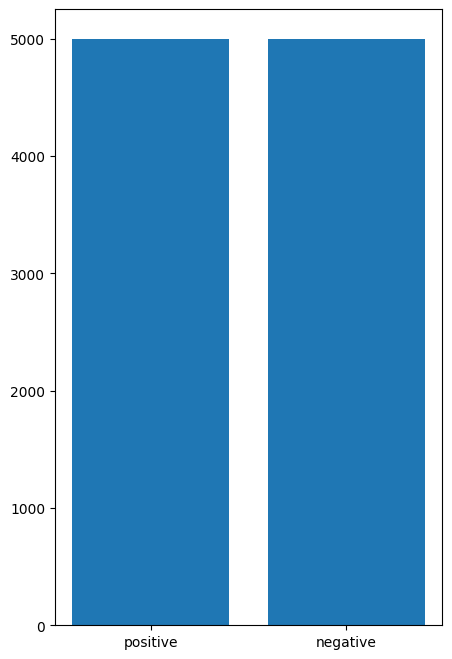

In [ ]:
fig=plt.figure(figsize=(5,8))
labels=["positive","negative"]
sizes=[y_positive,y_negative]
plt.bar(labels,sizes)
plt.show()

In [ ]:
tweet1=all_tweets_df.iloc[1000]
tweet1["Tweets"]

'@djcunningham Thanks for the favorite! :) Make sure to keep in touch for more news of our light bulbs made from corn waste.'

In [ ]:
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from nltk.stem import PorterStemmer


In [ ]:
tweet2=re.sub(r"RT[\s]+","",tweet1["Tweets"])
tweet2=re.sub(r"https?://[^\s\n\r]+","",tweet2)
tweet2=re.sub(r"#","",tweet2)
tweet2=re.sub(r"@","",tweet2)
tweet2=re.sub(r"[:)|(:]"," ",tweet2)
print(tweet1["Tweets"])
print("\n cleaned tweets:  \n",tweet2)


@djcunningham Thanks for the favorite! :) Make sure to keep in touch for more news of our light bulbs made from corn waste.

 cleaned tweets:  
 djcunningham Thanks for the favorite!    Make sure to keep in touch for more news of our light bulbs made from corn waste.


In [ ]:
tokenizer=TweetTokenizer(preserve_case=False,strip_handles=True,reduce_len=True)
tweet_tokens=tokenizer.tokenize(tweet2)
print()
print("tokenized string")
print(tweet_tokens)


tokenized string
['djcunningham', 'thanks', 'for', 'the', 'favorite', '!', 'make', 'sure', 'to', 'keep', 'in', 'touch', 'for', 'more', 'news', 'of', 'our', 'light', 'bulbs', 'made', 'from', 'corn', 'waste', '.']


In [ ]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stopwords_english=stopwords.words("english")
print("stopwords\n")
print(stopwords_english)
print("\nPunctuations\n")
print(string.punctuation)

stopwords

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "sh

In [ ]:
print(tweet_tokens)
tweets_clean=[]

for word in tweet_tokens:
  if (word not in stopwords_english and word not in string.punctuation):
    tweets_clean.append(word)

print("\ncleaned tweets:")
print(tweets_clean)

['djcunningham', 'thanks', 'for', 'the', 'favorite', '!', 'make', 'sure', 'to', 'keep', 'in', 'touch', 'for', 'more', 'news', 'of', 'our', 'light', 'bulbs', 'made', 'from', 'corn', 'waste', '.']

cleaned tweets:
['djcunningham', 'thanks', 'favorite', 'make', 'sure', 'keep', 'touch', 'news', 'light', 'bulbs', 'made', 'corn', 'waste']


In [ ]:
def process_tweet(tweet):
  tokenizer=TweetTokenizer(preserve_case=False,strip_handles=True,reduce_len=True)
  # The 'tweet' argument is already the tweet string, so no need for tweet["Tweets"]
  tweet=re.sub(r"RT[\s]+","",tweet)
  tweet=re.sub(r"https?://[^\s\n\r]+","",tweet)
  tweet=re.sub(r"#","",tweet)
  tweet=re.sub(r"@","",tweet)
  tweet=re.sub(r"[:)|(:]"," ",tweet)
  tweet_tokens=tokenizer.tokenize(tweet)
  tweets_clean=[]
  for word in tweet_tokens:
    if (word not in stopwords_english and word not in string.punctuation):
      tweets_clean.append(word)
  return tweets_clean

In [ ]:
processed_tweets=all_tweets_df["Tweets"].apply(process_tweet)
all_tweets_df["Tweets_processed"]=processed_tweets
pd.set_option("display.max_colwidth",None)
all_tweets_df

,Tweets,sentiments,Tweets_processed
0,"I love you, how but you? @Taecyeon2pm8 did you feel the same? Emm I think not :(",negative,"[love, taecyeon, 2pm8, feel, emm, think]"
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_ahmd @armansushita8 Thanks Guys :),positive,"[mayusushita, dildeewana, sonalp, 2591, deepti_ahmd, armansushita, 8, thanks, guys]"
2,"Your love, O Lord, is better than life. :) &lt;3 https://t.co/KPCeYJqKLM",positive,"[love, lord, better, life, <3]"
3,@yasminyasir96 yeah but it will be better if we use her official Account :) Like The Other @PracchiNDesai ❤️,positive,"[yasminyasir, 96, yeah, better, use, official, account, like, pracchindesai, ❤, ️]"
4,Ok good night I wish troye wasn't ugly and I met him today:)():)!:!; but ok today was fun I'm excited for tmrw!!,positive,"[ok, good, night, wish, troye, ugly, met, today, ok, today, fun, excited, tmrw]"
...,...,...,...
9995,My nose and forehead are peeling :(,negative,"[nose, forehead, peeling]"
9996,@LittleMix come to Belgium :(,negative,"[littlemix, come, belgium]"
9997,WHY MUST THE VIDEO STOP THO :(,negative,"[must, video, stop, tho]"
9998,@jeremygutsche we like this amazing donut recipe! we share with #foiegras lovers! :),positive,"[jeremygutsche, like, amazing, donut, recipe, share, foiegras, lovers]"
